In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Loading and viewing Dataset

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline


In [3]:
train=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [7]:
train.head(3)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2


In [4]:
print(train.shape)
print(test.shape)

(198000, 15)
(102000, 14)


In [9]:
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 

In [10]:
#train.value_counts()


In [11]:
print(train.describe())
train['upvote'].median()

             post_id     emoticon_1     emoticon_2     emoticon_3  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean       68.447429       0.279768       0.048338       0.121071   
std        27.948390       1.023234       0.258477       0.481013   
min        20.000000       0.000000       0.000000       0.000000   
25%        39.000000       0.000000       0.000000       0.000000   
50%        72.000000       0.000000       0.000000       0.000000   
75%        72.000000       0.000000       0.000000       0.000000   
max       129.000000      47.000000      11.000000      17.000000   

              upvote       downvote           if_1           if_2  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        2.607975       0.666394       1.906152       7.956212   
std         5.054763       2.044335      25.635752      14.839464   
min         0.000000       0.000000       0.000000       3.000000   
25%         0.000000       0.0000

1.0

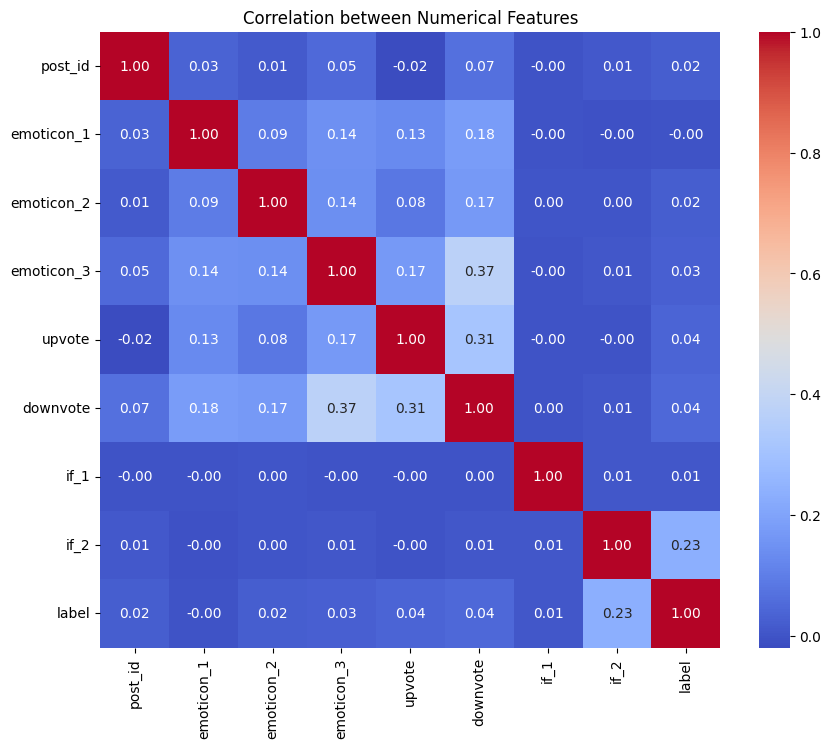

In [15]:
plt.figure(figsize=(10, 8))

numeric_cols = train.select_dtypes(include=['number']).columns
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Numerical Features')
plt.show()

<Axes: xlabel='gender', ylabel='count'>

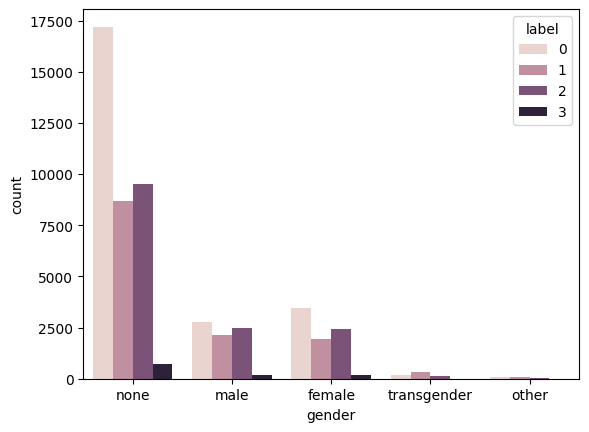

In [16]:
sns.countplot(x='gender', hue='label', data=train)


<Axes: xlabel='race', ylabel='count'>

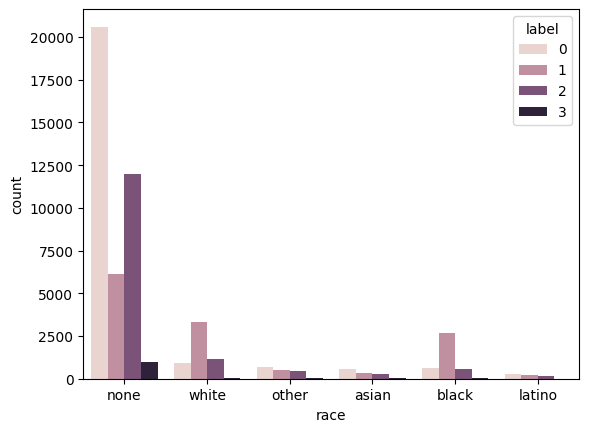

In [17]:
sns.countplot(x='race', hue='label', data=train)

<Axes: xlabel='race', ylabel='count'>

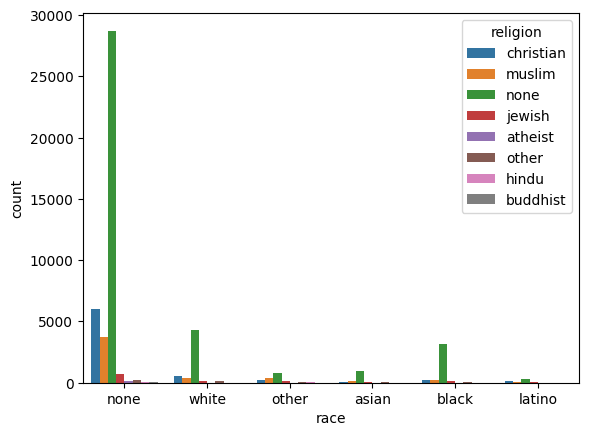

In [18]:

sns.countplot(x='race', hue='religion', data=train)

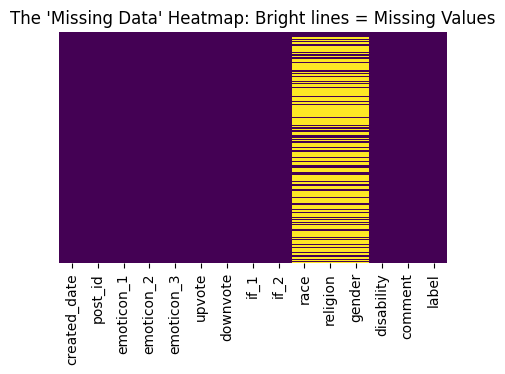

In [12]:
plt.figure(figsize=(5, 3))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("The 'Missing Data' Heatmap: Bright lines = Missing Values")
plt.show()

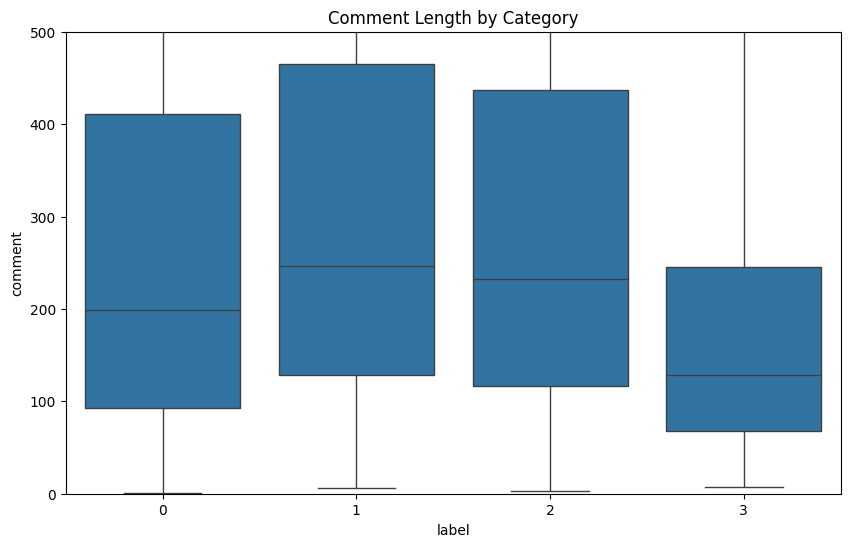

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x=train['label'],
    y=train['comment'].astype(str).apply(len)
)
plt.title('Comment Length by Category')
plt.ylim(0, 500)
plt.show()

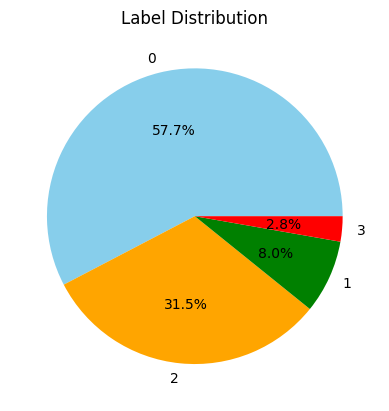

In [13]:
label_counts = train['label'].value_counts()
label_percent = 100 * label_counts / len(train)

label_percent.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue','orange','green','red'])
plt.ylabel("")  # Remove y-label
plt.title("Label Distribution")
plt.show()

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

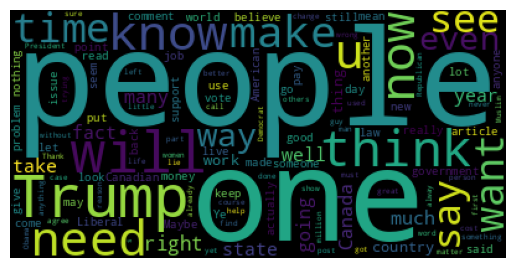

In [19]:
from wordcloud import WordCloud

text = " ".join(train['comment'].astype(str))
wc = WordCloud().generate(text)

plt.imshow(wc)
plt.axis('off')

In [ ]:
train['comments']

# Filling the missing values

In [20]:
train['race'].value_counts()

race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

In [5]:
l=['race','religion','gender']
for i in l:
    print(f"{i}: ",train[i].unique())

race:  [nan 'none' 'white' 'other' 'asian' 'black' 'latino']
religion:  [nan 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'
 'buddhist']
gender:  [nan 'none' 'male' 'female' 'transgender' 'other']


In [6]:
for i in l:
    train[i] = train[i].replace(['', 'none'], 'unknown').fillna('unknown')
    test[i]=test[i].replace(['', 'none'], 'unknown').fillna('unknown')
    
train['comment'] = train['comment'].fillna('')
test['comment']=test['comment'].fillna('')    
print("Missing value is replaced by unknown")

Missing value is replaced by unknown


In [7]:
train['disability'] = train['disability'].astype(int)
test['disability'] = test['disability'].astype(int)

train['created_date'] = pd.to_datetime(train['created_date'])
train['month'] = train['created_date'].dt.month_name().str.lower()

test['created_date'] = pd.to_datetime(test['created_date'])
test['month'] = test['created_date'].dt.month_name().str.lower()

In [7]:
train['race'].value_counts()


race
unknown    185105
white        5486
black        3869
other        1654
asian        1263
latino        623
Name: count, dtype: int64

In [8]:
train.head(3)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,month
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,unknown,unknown,unknown,0,She might be a bright spot for a party keou on...,2,january
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,unknown,unknown,unknown,0,"Under Alaska law, a non-tribal member is not b...",0,march
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,unknown,unknown,unknown,0,in the future please spare me your strawman dr...,2,april


# Buildings Models

In [8]:
train.drop(columns=['created_date', 'post_id','emoticon_1','gender',], inplace=True)
test.drop(columns=['created_date', 'post_id','emoticon_1','gender',], inplace=True)

X = train.drop('label', axis=1)   
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y )

X_train.head(3)


,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,disability,comment,month
180416,0,0,3,0,0,4,unknown,unknown,0,As a Baptist I will leave any theological diff...,september
135808,0,0,1,0,0,4,unknown,unknown,0,Ah ha ha ha ha ha ha ha ha ha ha ha ha ha ha h...,june
130514,0,0,1,0,0,10,unknown,unknown,0,"I'm quite sure Deborah Coyne is his cousin, wh...",november


# Preprocessing

                                                                 **Types of models** 

Model1: LogisticRegression

Training Complete! The model has finished studying.|               
Best C: {'model__C': 0.6}|                              
Best CV Score: 0.899810606060606|                      
Val Score: 0.8996464646464647|                         
{0: 1,2: 1,1: 1.5,3: 2 } -> 0.8094633972087693| 0.79861       
{0: 0.8,2: 1,1: 1.5,3: 2.2 }->0.8112400253303172|      
{0: 0.7,2: 1,1: 1.5,3: 2.5  }->0.812434332841537| 0.80916           
{0:0.5,2: 1,1: 2,3: 3 } ->0.8102428965248358            
{0:0.5,2: 1,1: 1.5,3: 3 }->0.8103842276277051

Training Complete! The model has finished studying.|
Best C: {'model__C': 0.6}|
Best CV Score: 0.899810606060606|
Val Score: 0.8996464646464647|
{0: 1,2: 1,1: 1.5,3: 2 } -> 0.8094633972087693| 0.79861
{0: 0.8,2: 1,1: 1.5,3: 2.2 }->0.8112400253303172|
{0: 0.7,2: 1,1: 1.5,3: 2.5 }->0.812434332841537| 0.80916
{0:0.5,2: 1,1: 2,3: 3 } ->0.8102428965248358
{0:0.5,2: 1,1: 1.5,3: 3 }->0.8103842276277051

In [13]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder , LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Model Imports
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# 1. PREPROCESSOR SETUP
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),["emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2", "disability"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["race", "religion"]),
        ("text", TfidfVectorizer(max_features=8000,stop_words='english', min_df=5, max_df=0.95, sublinear_tf=True, ), "comment")
    ]
)

# 2. CLASS WEIGHTS
#{0: 0.7, 2: 1, 1: 1.5, 3: 2.5}
weights = {0: 0.7, 2: 1, 1: 1.5, 3: 2.5}

In [ ]:
print("--- Logistic Regression: Method 1 (Standard Fit) ---")
log_reg = LogisticRegression(max_iter=10000, class_weight=weights, solver="saga")

pipe_lr = Pipeline([
    ("preprocess", preprocessor),
    ("model", log_reg)
])

pipe_lr.fit(X_train, y_train)
print(classification_report(y_val, pipe_lr.predict(X_val)))

In [15]:
print("Coefficients:", log_reg.coef_)


Coefficients: [[-0.02035878 -0.00402896  0.01273607 ... -0.04199378  0.13322012
   0.05108674]
 [ 0.01210438  0.01201228  0.01982188 ...  0.12541632  0.00474243
  -0.42861139]
 [-0.02120856 -0.01796955  0.03529039 ...  0.09831116 -0.07663681
   0.14994753]
 [ 0.02946297  0.00998623 -0.06784833 ... -0.1817337  -0.06132574
   0.22757712]]


In [17]:
print("Intercept:", log_reg.intercept_)

Intercept: [ 0.03626082  0.0380667  -0.0114723  -0.06285521]


In [30]:
# for OneHotEncoder 
#                 precision    recall  f1-score   support

#            0       0.97      0.94      0.96     22835
#            1       0.75      0.76      0.76      3183
#            2       0.85      0.90      0.87     12488
#            3       0.66      0.61      0.63      1094

#     accuracy                           0.91     39600
#    macro avg       0.81      0.80      0.80     39600
# weighted avg       0.91      0.91      0.91     39600

In [35]:
from sklearn import set_config
set_config(display='diagram')

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['emoticon_2', 'emoticon_3', 'upvote',
                                  'downvote', 'if_1', 'if_2', 'disability']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['race', 'religion']),
                                ('text',
                                 TfidfVectorizer(max_df=0.95, max_features=8000,
                                                 min_df=2, sublinear_tf=True),
                                 'comment')])

In [31]:
# print("--- Logistic Regression: Method 2 (GridSearchCV) ---")
# log_reg = LogisticRegression(max_iter=10000, class_weight=weights, solver="saga")

# pipe_lr_grid = Pipeline([
#     ("preprocess", preprocessor),
#     ("model", log_reg)
# ])

# param_grid_lr = {"model__C": [0.5, 0.6, 0.7, 1, 2]}

# grid_lr = GridSearchCV(pipe_lr_grid, param_grid_lr, cv=3, scoring="f1_macro", n_jobs=-1)
# grid_lr.fit(X_train, y_train)

# print("Best Parameters:", grid_lr.best_params_)
# print("Best CV Score (F1 Macro):", grid_lr.best_score_)
# print("Validation Score (F1 Macro):", grid_lr.score(X_val, y_val))

# # Save best model
# best_log_reg = grid_lr.best_estimator_

--- Logistic Regression: Method 2 (GridSearchCV) ---


KeyboardInterrupt: 

In [ ]:
print("--- LinearSVC: Method 1 (Standard Fit) ---")
svc = LinearSVC(max_iter=1000, class_weight=weights, dual=False)

pipe_svc = Pipeline([
    ("preprocess", preprocessor),
    ("model", svc)
])

pipe_svc.fit(X_train, y_train)
print(classification_report(y_val, pipe_svc.predict(X_val)))

In [ ]:
# print("--- LinearSVC: Method 2 (GridSearchCV) ---")
# svc = LinearSVC(max_iter=10000, class_weight=weights, dual=False)

# pipe_svc_grid = Pipeline([
#     ("preprocess", preprocessor),
#     ("model", svc)
# ])

# param_grid_svc = {"model__C":[0.01, 0.1, 0.5, 1, 2]}

# grid_svc = GridSearchCV(pipe_svc_grid, param_grid_svc, cv=3, scoring="f1_macro", n_jobs=-1)
# grid_svc.fit(X_train, y_train)

# print("Best Parameters:", grid_svc.best_params_)
# print("Best CV Score (F1 Macro):", grid_svc.best_score_)
# print("Validation Score (F1 Macro):", grid_svc.score(X_val, y_val))

# # Save best model
# best_svc = grid_svc.best_estimator_

In [11]:
print("--- Random Forest: Method 1 (Standard Fit) ---")
weights = {0: 0.7, 2: 1, 1: 1.5, 3: 3.5}
rf = RandomForestClassifier(class_weight=weights, random_state=42,n_estimators=100,n_jobs=-1)

pipe_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf)
])

pipe_rf.fit(X_train, y_train)
print(classification_report(y_val, pipe_rf.predict(X_val)))

--- Random Forest: Method 1 (Standard Fit) ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.75      0.72      0.73      3183
           2       0.82      0.91      0.86     12488
           3       0.84      0.30      0.44      1094

    accuracy                           0.90     39600
   macro avg       0.84      0.72      0.75     39600
weighted avg       0.90      0.90      0.90     39600



In [22]:
{0: 0.7, 2: 1, 1: 1.5, 3: 2.5}  ->  0.76  
# --- Random Forest: Method 1 (Standard Fit) ---
#               precision    recall  f1-score   support

#            0       0.97      0.95      0.96     22835
#            1       0.75      0.73      0.74      3183
#            2       0.82      0.91      0.86     12488
#            3       0.83      0.31      0.45      1094

#     accuracy                           0.90     39600
#    macro avg       0.84      0.72      0.75     39600
# weighted avg       0.90      0.90      0.90     39600

In [ ]:
# print("--- Random Forest: Method 2 (GridSearchCV) ---")
# rf = RandomForestClassifier(class_weight=weights, random_state=42)

# pipe_rf_grid = Pipeline([
#     ("preprocess", preprocessor),
#     ("model", rf)
# ])

# param_grid_rf = {
#     "model__n_estimators": [100, 200],
#     "model__max_depth": [None, 20] 
# }

# # If it crashes again, change n_jobs=-1 to n_jobs=2
# grid_rf = GridSearchCV(pipe_rf_grid, param_grid_rf, cv=3, scoring="f1_macro", n_jobs=-1)
# grid_rf.fit(X_train, y_train)

# print("Best Parameters:", grid_rf.best_params_)
# print("Best CV Score (F1 Macro):", grid_rf.best_score_)
# print("Validation Score (F1 Macro):", grid_rf.score(X_val, y_val))

# # Save best model
# best_rf = grid_rf.best_estimator_

In [24]:
from lightgbm import LGBMClassifier


weights = {0: 0.7, 2: 1, 1: 1.5, 3: 2.5}
# This model is designed for speed and handles imbalanced classes natively
lgbm = LGBMClassifier(
    class_weight=weights,
    n_estimators=200,      
    learning_rate=0.05,     # Smaller learning rate for better stability
    num_leaves=31,          # Standard size
    reg_alpha=0.1,          # L1 regularization
    reg_lambda=0.1,         # L2 regularization
    min_child_samples=20,   # Prevents overfitting small clusters
    random_state=42,
    n_jobs=-1
)



# SVD converts 8,000 word-features into 300 "Concept" features
svd = TruncatedSVD(n_components=300, random_state=42)

pipe_lgbm = Pipeline([
    ("preprocess", preprocessor),
    ("model", lgbm)
])

pipe_lgbm.fit(X_train, y_train)
print(classification_report(y_val, pipe_lgbm.predict(X_val)))

# Use 'lgbm' in your pipeline instead of 'rf'

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 7.676991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 681504
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 8021
[LightGBM] [Info] Start training from score -0.811425
[LightGBM] [Info] Start training from score -2.019498
[LightGBM] [Info] Start training from score -1.058255
[LightGBM] [Info] Start training from score -2.577120


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.81      0.77      3183
           2       0.86      0.90      0.88     12488
           3       0.66      0.58      0.62      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.81      0.81     39600
weighted avg       0.91      0.91      0.91     39600



In [ ]:
weights = {0: 0.7, 2: 1, 1: 1.5, 3: 2.5}
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.81      0.77      3183
           2       0.87      0.90      0.88     12488
           3       0.63      0.63      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.80      0.82      0.81     39600
weighted avg       0.91      0.91      0.91     39600


In [23]:
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Define your LGBM Model (The "Engine")
# These custom weights help keep Precision stable
weights = {0: 0.7, 1: 1.5, 2: 1, 3: 3}

lgbm = LGBMClassifier(
    class_weight=weights,
    n_estimators=200,      
    learning_rate=0.05,
    num_leaves=31,
    reg_alpha=0.1,
    reg_lambda=0.1,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1
)

# 2. Calibration (The "Optimizer")
# FIXED: Changed 'lr' to 'lgbm'. 
# This makes the probabilities (0.0 to 1.0) mathematically accurate.
calibrated_lgbm = CalibratedClassifierCV(lgbm, cv=5, method='sigmoid')

# 3. Simple Pipeline (NO SVD - Keep the raw word features for long sentences)
pipe_final = Pipeline([
    ("preprocess", preprocessor),
    ("model", calibrated_lgbm)
])

# 4. Fit the model
pipe_final.fit(X_train, y_train)

# 5. Get Calibrated Probabilities
probs = pipe_final.predict_proba(X_val)

# 6. Smart Thresholding (The "Aggressive Search")
# 0.40 is a great balance. If the model is 40% sure it's Class 3, we flag it.
threshold = 0.40
y_pred_custom = np.argmax(probs, axis=1) # Standard prediction logic
y_pred_custom = np.where(probs[:, 3] > threshold, 3, y_pred_custom) # Class 3 Override

# 7. Final Report
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred_custom))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 6.512421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 584473
[LightGBM] [Info] Number of data points in the train set: 126720, number of used features: 8021
[LightGBM] [Info] Start training from score -0.826516
[LightGBM] [Info] Start training from score -2.034583
[LightGBM] [Info] Start training from score -1.073330
[LightGBM] [Info] Start training from score -2.409884


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 6.460761 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 584775
[LightGBM] [Info] Number of data points in the train set: 126720, number of used features: 8021
[LightGBM] [Info] Start training from score -0.826516
[LightGBM] [Info] Start training from score -2.034583
[LightGBM] [Info] Start training from score -1.073330
[LightGBM] [Info] Start training from score -2.409884


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 6.398337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 583761
[LightGBM] [Info] Number of data points in the train set: 126720, number of used features: 8021
[LightGBM] [Info] Start training from score -0.826516
[LightGBM] [Info] Start training from score -2.034583
[LightGBM] [Info] Start training from score -1.073330
[LightGBM] [Info] Start training from score -2.409884


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 6.377510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 584227
[LightGBM] [Info] Number of data points in the train set: 126720, number of used features: 8021
[LightGBM] [Info] Start training from score -0.826500
[LightGBM] [Info] Start training from score -2.034581
[LightGBM] [Info] Start training from score -1.073352
[LightGBM] [Info] Start training from score -2.409881


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 6.431390 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 584528
[LightGBM] [Info] Number of data points in the train set: 126720, number of used features: 8021
[LightGBM] [Info] Start training from score -0.826500
[LightGBM] [Info] Start training from score -2.034581
[LightGBM] [Info] Start training from score -1.073352
[LightGBM] [Info] Start training from score -2.409881


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.76      0.79      0.77      3183
           2       0.86      0.91      0.88     12488
           3       0.67      0.57      0.62      1094

    accuracy                           0.91     39600
   macro avg       0.82      0.80      0.81     39600
weighted avg       0.91      0.91      0.91     39600



In [12]:
from sklearn.ensemble import VotingClassifier

# Create the ensemble
voter = VotingClassifier(
    estimators=[
        ('rf', pipe_rf), # Your Random forest pipeline
        ('lgbm', pipe_lgbm) # Your LightGBM pipeline
    ],
    voting='soft' # Uses probabilities for a "smarter" average
)

voter.fit(X_train, y_train)
print(classification_report(y_val, voter.predict(X_val)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 8.355578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 739253
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 8021
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.71      0.82      0.76      3183
           2       0.87      0.88      0.88     12488
           3       0.63      0.65      0.64      1094

    accuracy                           0.91     39600
   macro avg       0.80      0.82      0.81     39600
weighted avg       0.91      0.91      0.91     39600



In [ ]:
# 1. Generate predictions using your winning model
# Change 'best_svc' to your best performing pipeline variable!
#test_predictions = best_svc.predict(X_val)   pipe_lr
# 1. LOAD YOUR TEST DATA FIRST
# (Replace 'test.csv' with whatever your test file is named in the competition)


# 2. MAKE PREDICTIONS ON THE TEST DATA
test_predictions = pipe_lr.predict(test)

# 3. CREATE THE DATAFRAME
submission = pd.DataFrame({
    'ID': sample['ID'],      
    'label': test_predictions
})

# 4. SAVE IT
submission['label'] = submission['label'].astype(int)
submission.to_csv('submission.csv', index=False)

print("Submission file saved!")
print(submission.head(3))

................................................................................................

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Replace these values with your actual results
data = {
    'Model': ['Random Forest', 'Logistic Regression', 'LightGBM', 'Calibrated LGBM', 'Voting Ensemble','Linear SVC'],
    'Accuracy': [0.90, 0.91, 0.91, 0.91, 0.91, 0.81],
    'Macro_F1': [0.75, 0.81, 0.81, 0.81, 0.81, 0.70],
    'Class3_Precision': [0.83, 0.59, 0.66, 0.67, 0.63, 0.55],
    'Class3_Recall': [0.31, 0.70, 0.58, 0.57, 0.65, 0.48]
}

df = pd.DataFrame(data)

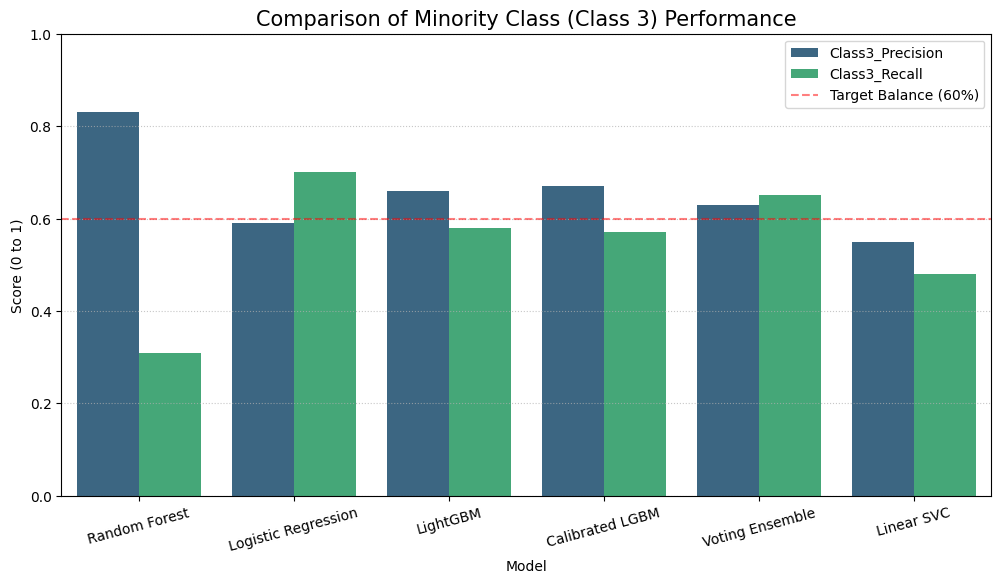

In [27]:
plt.figure(figsize=(12, 6))
df_melted = df.melt(id_vars='Model', value_vars=['Class3_Precision', 'Class3_Recall'], var_name='Metric', value_name='Score')

sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.axhline(0.60, color='red', linestyle='--', alpha=0.5, label='Target Balance (60%)')
plt.title('Comparison of Minority Class (Class 3) Performance', fontsize=15)
plt.ylabel('Score (0 to 1)')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

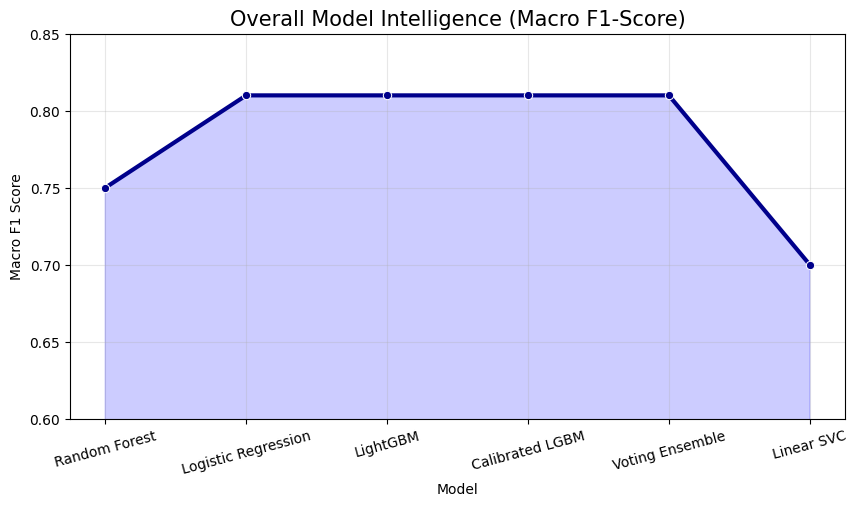

In [29]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Model', y='Macro_F1', marker='o', sort=False, color='darkblue', linewidth=3)
plt.fill_between(df['Model'], df['Macro_F1'], alpha=0.2, color='blue')
plt.title('Overall Model Intelligence (Macro F1-Score)', fontsize=15)
plt.ylabel('Macro F1 Score')
plt.ylim(0.60, 0.85) # Zoom in to see the differences
plt.grid(True, alpha=0.3)
plt.xticks(rotation=15)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


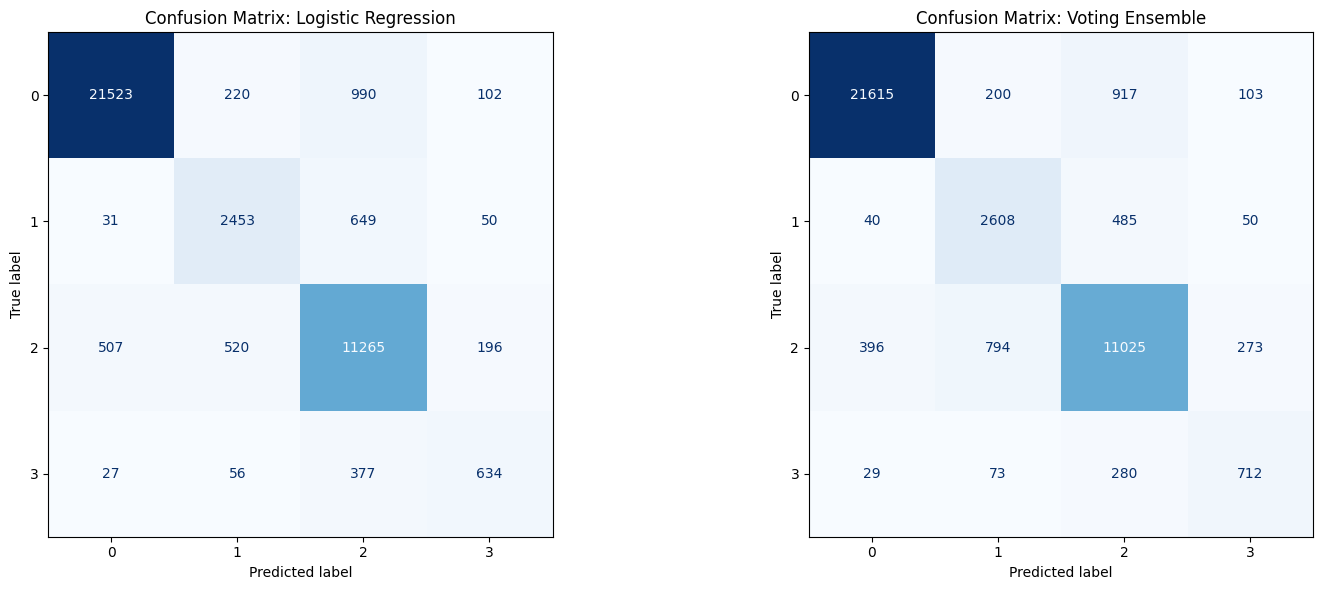

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Note: You need to run this cell where your fitted models exist
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_to_compare = [('Logistic Regression', pipe_lr), ('Voting Ensemble', voter)]

for i, (name, model) in enumerate(models_to_compare):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import VotingClassifier

# 1. Take your two best performers
# (Make sure pipe_lr and pipe_rf/lgbm are already defined)
super_model = VotingClassifier(
    estimators=[
        ('lr', pipe_lr),             # Your high-recall Logistic Regression
        ('voting_base', voter) # Your already-balanced Voting Ensemble
    ],
    voting='soft',   # 'soft' uses probabilities, which is better for imbalanced data
    weights=[1, 1]   # You can give more weight to one if you prefer
)

# 2. Fit the Super Model
super_model.fit(X_train, y_train)

# 3. Analyze the results
from sklearn.metrics import classification_report, confusion_matrix
y_pred = super_model.predict(X_val)

print("--- Super Ensemble Results ---")
print(classification_report(y_val, y_pred))

In [ ]:
--- Super Ensemble Results ---
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.80      0.77      3183
           2       0.86      0.90      0.88     12488
           3       0.68      0.62      0.65      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.82      0.81     39600
weighted avg       0.91      0.91      0.91     39600

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_super_model = StackingClassifier(
    estimators=[
        ('lr', pipe_lr),
        ('voting', voter)
    ],
    final_estimator=LogisticRegression(), # The "Judge"
    cv=5
)

stacking_super_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 8.099040 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 739253
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 8021
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


#                                                                    THE END

# MileStone 1

In [ ]:
import pandas as pd

train=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [ ]:
print("train: ",train.shape)
print("test: ",test.shape)

In [ ]:
print("Train Dataset")
print(train.info())

In [ ]:
train['label'].unique()

In [ ]:
count=0
for i in train['label']:
    if i==0:
        count+=1
print(count) 

In [ ]:
train.describe()

# MileStone 2

In [ ]:
train['created_date'] = pd.to_datetime(train['created_date'])
train['month'] = train['created_date'].dt.month_name().str.lower()

test['created_date'] = pd.to_datetime(test['created_date'])
test['month'] = test['created_date'].dt.month_name().str.lower()

most_common_month = train['month'].value_counts().idxmax()
print(most_common_month)

In [ ]:
train.head(3)

In [ ]:
train['total_emoticons'] = (train['emoticon_1'] + train['emoticon_2'] + train['emoticon_3'])

max_value = train['total_emoticons'].max()
print(max_value)

In [ ]:
train['comment'] = train['comment'].fillna('')
label_3 = train[train['label'] == 3]
comment_lengths = label_3['comment'].str.len()
median_length = comment_lengths.median()
print(median_length)

In [ ]:
train['comment'] = train['comment'].fillna('')
label_1 = train[train['label'] == 1]
word_counts = label_1['comment'].str.split().str.len()
average_word_count = round(word_counts.mean(), 2)
print(average_word_count)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform the upvote column
train['upvote_scaled'] = scaler.fit_transform(train[['upvote']])
scaled_value_for_10 = scaler.transform([[10]])
print(scaled_value_for_10[0][0])

# MileStone 3

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming 'train' is your initial DataFrame and 'target' is your label column
# Replace 'target' with the actual name of your target column
X = train.drop(columns=['label']) 
y = train['label']

# Split the data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

# Get number of rows
a = X_train.shape[0]
c = X_val.shape[0]

# Calculate a + c
total_rows = a + c

print(f"Value of a (training rows): {a}")
print(f"Value of c (validation rows): {c}")
print(f"Value of a + c: {total_rows}")

# Logic check: This should be equal to the length of the original train dataset
# print(len(train))

In [ ]:
import pandas as pd

# 1. Convert created_date to datetime objects
X_train['created_date'] = pd.to_datetime(X_train['created_date'])
X_val['created_date'] = pd.to_datetime(X_val['created_date'])

# 2. Extract day, month, and year
# Training set
X_train['day'] = X_train['created_date'].dt.day
X_train['month'] = X_train['created_date'].dt.month
X_train['year'] = X_train['created_date'].dt.year

# Validation set
X_val['day'] = X_val['created_date'].dt.day
X_val['month'] = X_val['created_date'].dt.month
X_val['year'] = X_val['created_date'].dt.year

# 3. Identify the most frequent month in X_train
most_frequent_month = X_train['month'].mode()[0]

print(f"The most frequent month is: {most_frequent_month}")


In [ ]:
X_train['month'].unique()

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Identify categorical columns and impute nulls with 'none'
# We apply this to all categorical columns (object type)
cat_cols = X_train.select_dtypes(include=['object']).columns

X_train[cat_cols] = X_train[cat_cols].fillna('none')
X_val[cat_cols] = X_val[cat_cols].fillna('none')

# 2. Define the features to One-Hot Encode
ohe_features = ['religion', 'gender', 'race']

# 3. Initialize OneHotEncoder with handle_unknown='ignore'
# We use sparse_output=False (or sparse=False) to easily convert back to DataFrame
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 4. Fit and Transform X_train, Transform X_val
# We transform only the specific columns
encoded_train = encoder.fit_transform(X_train[ohe_features])
encoded_val = encoder.transform(X_val[ohe_features])

# 5. Get the names of the new one-hot columns
encoded_cols = encoder.get_feature_names_out(ohe_features)

# 6. Create DataFrames from the encoded arrays
X_train_encoded_df = pd.DataFrame(encoded_train, columns=encoded_cols, index=X_train.index)
X_val_encoded_df = pd.DataFrame(encoded_val, columns=encoded_cols, index=X_val.index)

# 7. Drop original columns and join the new encoded columns
X_train = pd.concat([X_train.drop(columns=ohe_features), X_train_encoded_df], axis=1)
X_val = pd.concat([X_val.drop(columns=ohe_features), X_val_encoded_df], axis=1)

# Resulting shape
a, b = X_train.shape

print(f"Number of rows (a): {a}")
print(f"Number of columns after encoding (b): {b}")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Handle potential null values in the 'comment' column 
# (Previous instructions suggested imputing with 'none')
X_train['comment'] = X_train['comment'].fillna('none')
X_val['comment'] = X_val['comment'].fillna('none')

# 2. Initialize CountVectorizer
vectorizer = CountVectorizer()

# 3. Fit and transform X_train['comment'], and transform X_val['comment']
X_train_counts = vectorizer.fit_transform(X_train['comment'])
X_val_counts = vectorizer.transform(X_val['comment'])

# 4. Get the sum of counts for the document at index 1 (the second row)
# index 1 refers to the 2nd row of the sparse matrix
row_1_sum = X_train_counts[1].sum()

print(f"The sum of counts for the document at index 1 is: {row_1_sum}")

In [ ]:
X_train['disability'] = X_train['disability'].astype(int)
X_val['disability'] = X_val['disability'].astype(int)

# 2. Calculate the sum of 'disability' values in X_train and X_val
train_sum = X_train['disability'].sum()
val_sum = X_val['disability'].sum()

# 3. Calculate the total sum
total_sum = train_sum + val_sum

print(f"Sum in X_train: {train_sum}")
print(f"Sum in X_val: {val_sum}")
print(f"Total sum across both: {total_sum}")

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Drop all datetime columns
# Identify columns with datetime types
datetime_cols = X_train.select_dtypes(include=['datetime64']).columns
X_train = X_train.drop(columns=datetime_cols)
X_val = X_val.drop(columns=datetime_cols)

# 2. Identify numeric features
# This includes int and float types (including our new day/month/year and OHE columns)
numeric_features = X_train.select_dtypes(include=['int64', 'float64', 'int32']).columns

# 3. Initialize and fit StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[numeric_features])

# 4. Transform both datasets
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

X_train_scaled[numeric_features] = scaler.transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])

# 5. Get the number of features seen during fit
num_features = scaler.n_features_in_

print(f"Number of features seen during fit: {num_features}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score

# --- 0. Initial Split ---
# Assuming 'train' is your original full dataframe and 'target' is the label
X = train.drop(columns=['label'])
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

# --- 1. Date Engineering ---
def engineer_dates(df):
    df = df.copy()
    df['created_date'] = pd.to_datetime(df['created_date'])
    df['day'] = df['created_date'].dt.day
    df['month'] = df['created_date'].dt.month
    df['year'] = df['created_date'].dt.year
    return df.drop(columns=['created_date'])

X_train = engineer_dates(X_train)
X_val = engineer_dates(X_val)

# Handle 'disability' if it exists (converting boolean to int for the imputer/NB)
if 'disability' in X_train.columns:
    X_train['disability'] = X_train['disability'].astype(int)
    X_val['disability'] = X_val['disability'].astype(int)

# --- 2. Define Column Groups ---
text_feature = 'comment'
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove(text_feature)  # Don't One-Hot Encode the text column
numeric_features = X_train.select_dtypes(exclude=['object']).columns.tolist()

# --- 3. Build Preprocessing Pipelines ---

# Numeric Pipeline: Impute -> Absolute Value
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('abs', FunctionTransformer(np.abs)) # Ensure no negative values for MultinomialNB
])

# Categorical Pipeline: Impute -> One Hot Encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer([
    ('tfidf', TfidfVectorizer(stop_words='english'), text_feature),
    ('cat', cat_pipeline, categorical_features),
    ('num', num_pipeline, numeric_features)
])

# --- 4. Final Pipeline with MultinomialNB ---
clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MultinomialNB())
])

# Fit the model
clf_pipeline.fit(X_train, y_train)

# --- 5. Evaluate on Train Dataset ---
y_train_pred = clf_pipeline.predict(X_train)
macro_f1 = f1_score(y_train, y_train_pred, average='macro')

print(f"Macro F1 Score on Train Dataset: {macro_f1}")

In [ ]:
from sklearn.metrics import f1_score

# 1. Use the fitted pipeline to predict labels for the validation set
y_val_pred = clf_pipeline.predict(X_val)

# 2. Calculate the Macro F1 Score
macro_f1_val = f1_score(y_val, y_val_pred, average='macro')

print(f"Macro F1 Score on Validation Dataset: {macro_f1_val}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score

# 1. Initial Split (80% Train, 20% Val)
# Assuming 'data' is your full raw DataFrame and 'target' is the label column
X = train.drop(columns=['label'])
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Feature Engineering Function
def engineer_features(df):
    df = df.copy()
    # Convert to datetime
    df['created_date'] = pd.to_datetime(df['created_date'])
    
    # Extract day, month, year
    df['day'] = df['created_date'].dt.day
    df['month'] = df['created_date'].dt.month
    df['year'] = df['created_date'].dt.year
    
    # Create is_weekend (Saturday=5, Sunday=6)
    # We cast to string to ensure the OneHotEncoder treats it as categorical
    df['is_weekend'] = df['created_date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0).astype(str)
    
    # Drop original date column
    return df.drop(columns=['created_date'])

# Apply engineering to both sets
X_train = engineer_features(X_train)
X_val = engineer_features(X_val)

# Handle NaNs in text column specifically for TfidfVectorizer
X_train['comment'] = X_train['comment'].fillna('')
X_val['comment'] = X_val['comment'].fillna('')

# 3. Identify feature types for the ColumnTransformer
text_feature = 'comment'
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
if text_feature in categorical_features:
    categorical_features.remove(text_feature)

numeric_features = X_train.select_dtypes(exclude=['object']).columns.tolist()

# 4. Build Preprocessing Pipelines
# Numeric: Impute -> Absolute Value (MultinomialNB requires non-negative inputs)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('abs', FunctionTransformer(np.abs))
])

# Categorical: Impute -> One Hot Encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

# Combine everything into a ColumnTransformer
preprocessor = ColumnTransformer([
    ('tfidf', TfidfVectorizer(stop_words='english'), text_feature),
    ('cat', cat_pipeline, categorical_features),
    ('num', num_pipeline, numeric_features)
])

# 5. Final Model Pipeline
clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MultinomialNB())
])

# Fit the model on training data
clf_pipeline.fit(X_train, y_train)

# 6. Predict and Calculate Macro F1 Score on X_train
y_train_pred = clf_pipeline.predict(X_train)
macro_f1_train = f1_score(y_train, y_train_pred, average='macro')

print(f"Macro F1 score on training set: {round(macro_f1_train, 4)}")

In [ ]:
from sklearn.metrics import f1_score

# 1. Use the fitted pipeline to predict labels for the validation set (X_val)
# The pipeline automatically applies the Date engineering, Tfidf, Imputation, 
# Absolute value, and One-Hot Encoding to the validation data.
y_val_pred = clf_pipeline.predict(X_val)

# 2. Calculate the Macro F1 Score
macro_f1_val = f1_score(y_val, y_val_pred, average='macro')

# 3. Print the result rounded to four decimal places
print(f"Macro F1 score on validation set: {round(macro_f1_val, 4)}")